# **Machine Learning and Forecasting: Seminar 7**

In [32]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler , normalize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.statespace.tools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_white
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# Part A: Questions with hints

##A.1. Difficulty Level: Simple to Intermediate

Q1: Read the dataset *clustering_dataset.csv* into Python. The detailed description of this dataset can be found on https://archive.ics.uci.edu/dataset/9/auto+mpg. <font face="Calibri" size=2.5 color='#3543cd'> (Hint: to read your data into google colab and then check whether there are any string variables. If there are string variables, you need to transform them into numerical ones.
`. <font>

In [4]:
clustering_dataset = pd.read_csv("Datasets/Auto_MPG_Dataset.csv")

Q2: Use the single linkage hierarchical clustering method to cluster the dataset in Q1 and create a dengogram. Inspect the plot and determine the number of clusters. How many clusters do you suggest? <font face="Calibri" size=2.5 color='#3543cd'> (Hint: You can normalise your variables by importing library `from sklearn.preprocessing import StandardScaler, normalize` and applying the function `fit_transform`.  `linkage(Y, method ='ward')`, where `Y` is the dataset to be clustered. You also need to import a library with the statement `import scipy.cluster.hierarchy as sch` to use the function `linkage`. You can then import `from scipy.cluster.hierarchy import dendrogram, linkage` and `from scipy.cluster.hierarchy import dendrogram, linkage` for creating a dengogram. The single linkage can be used via `shc.dendrogram((shc.linkage(Y, method ='single')))`
`. <font>

In [14]:
scaler = StandardScaler()
clustering_dataset_scaled = scaler.fit_transform(clustering_dataset)
clustering_dataset = pd.DataFrame(clustering_dataset_scaled, columns=clustering_dataset.columns, index=clustering_dataset.index)

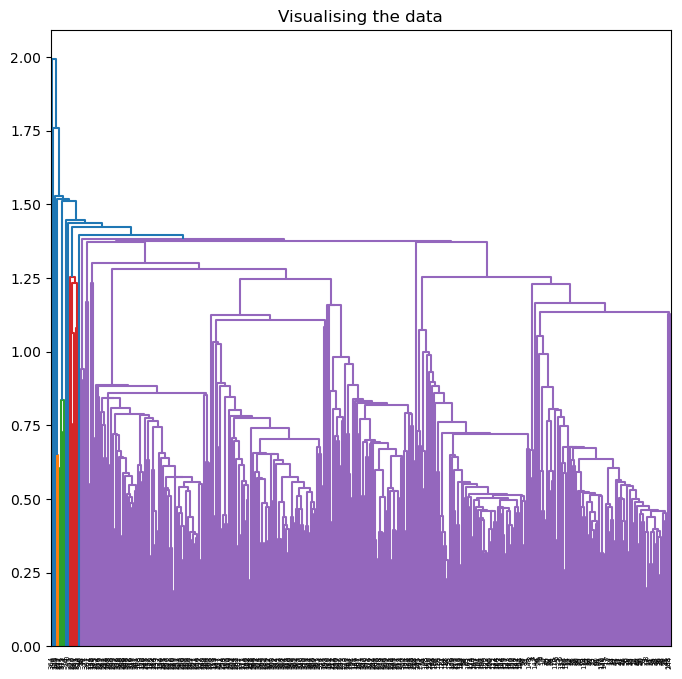

In [20]:
plt.figure(figsize =(8, 8))
plt.title('Visualising the data')
Dendrogram = shc.dendrogram((shc.linkage(clustering_dataset, method ='single')))

Q3: Use the complete linkage hierarchical clustering method to cluster the dataset in Q1 and create a dengogram. Inspect the plot and determine the number of clusters. How many clusters do you suggest? <font face="Calibri" size=2.5 color='#3543cd'> (Hint: The Python code is similar to that in Q2. The complete linkage can be used via `(shc.linkage(Y, method ='complete'))`.
`.
  <font>

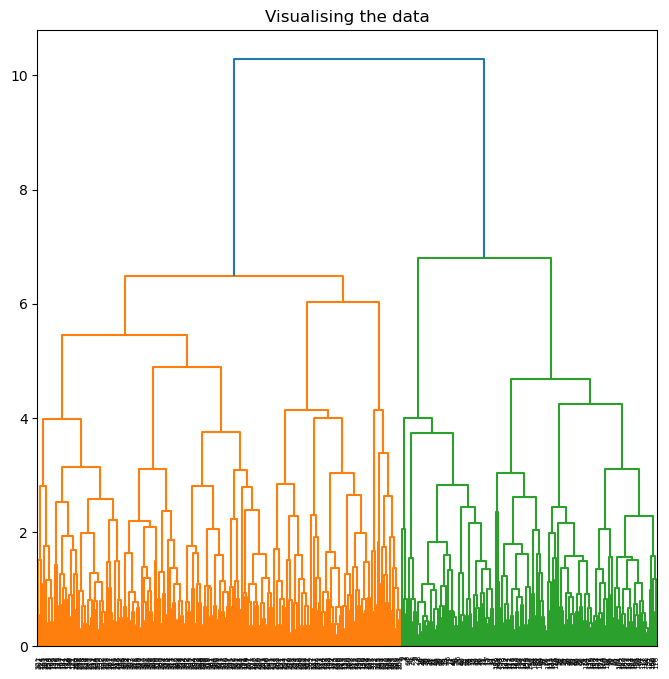

In [21]:
plt.figure(figsize =(8, 8))
plt.title('Visualising the data')
Dendrogram = shc.dendrogram((shc.linkage(clustering_dataset, method ='complete')))

Q4: Use Ward's hierarchical clustering method to cluster the dataset in Q1 and create a dengogram. Inspect the plot and determine the number of clusters. How many clusters do you suggest? <font face="Calibri" size=2.5 color='#3543cd'> (Hint: The Python code is similar to that in Q2 and Q3. The Ward's linkage can be used via `(shc.linkage(Y, method ='ward'))`.
  <font>

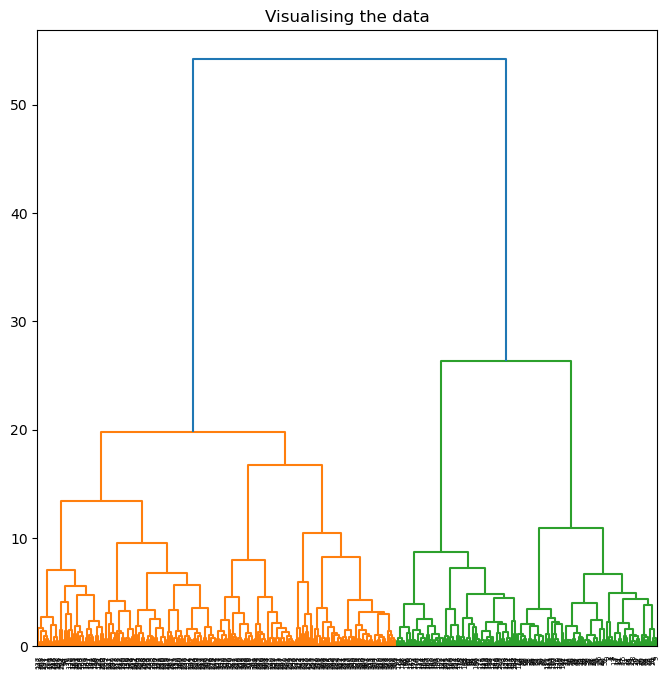

In [22]:
plt.figure(figsize =(8, 8))
plt.title('Visualising the data')
Dendrogram = shc.dendrogram((shc.linkage(clustering_dataset, method ='ward')))

Q5: Using the Euclidean distance as the distance measure and the Ward's clustering method, cluster the dataset in Q1 and then create a plot with $k$'s on the X-axis and the Silhouette scores on the $Y$-axis. Inspect the plot and determine the number of clusters. How many clusters do you suggest? Is the number of clusters agrees with the one you determined in Q2? <font face="Calibri" size=3.0 color='#3543cd'> (Hint: To use the silhouette scores, you need to import the library `silhouette_score` by the code `from sklearn.metrics import silhouette_score`. You also need the Euclidean distance and the Ward's method by importing the library via `from sklearn.cluster import AgglomerativeClustering` and  then specify `AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward', compute_distances=True)`. You may create a bar chart by specifying `plt.bar(k, silhouette_scores)`.
  <font>

<BarContainer object of 28 artists>

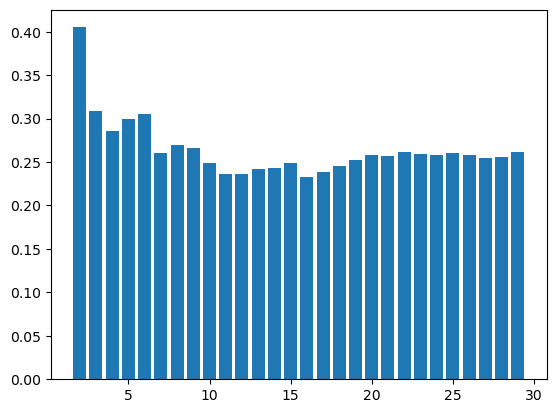

In [29]:
silhouette_scores = []
ks =[]
for k in range(2,30):
    clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward', compute_distances=True).fit(clustering_dataset)
    silhouette_scores.append(silhouette_score(clustering_dataset, clustering.fit_predict(clustering_dataset)))
    ks.append(k)

plt.bar(ks, silhouette_scores)

Q6: Among the above three clustering methods: Q2, Q3, and Q4, which clustering method outperforms?

<BarContainer object of 28 artists>

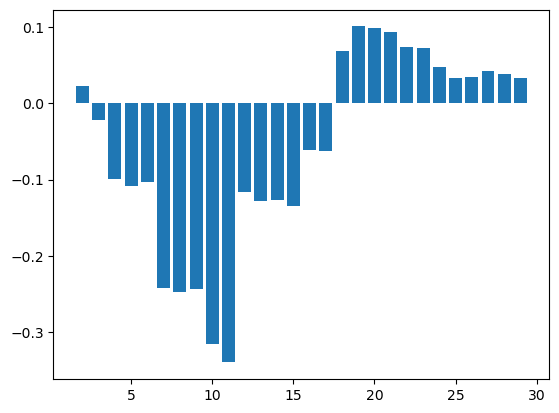

In [30]:
silhouette_scores = []
ks =[]
for k in range(2,30):
    clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='single', compute_distances=True).fit(clustering_dataset)
    silhouette_scores.append(silhouette_score(clustering_dataset, clustering.fit_predict(clustering_dataset)))
    ks.append(k)

plt.bar(ks, silhouette_scores)

<BarContainer object of 28 artists>

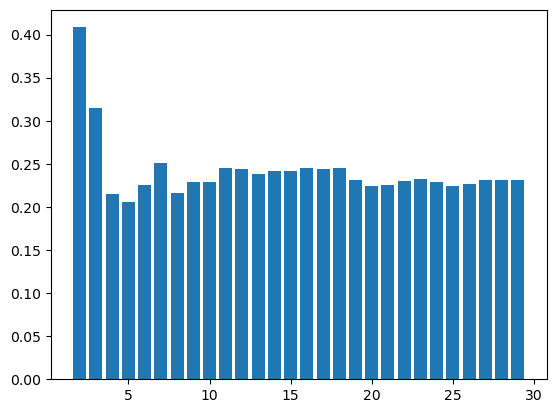

In [31]:
silhouette_scores = []
ks =[]
for k in range(2,30):
    clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='complete', compute_distances=True).fit(clustering_dataset)
    silhouette_scores.append(silhouette_score(clustering_dataset, clustering.fit_predict(clustering_dataset)))
    ks.append(k)

plt.bar(ks, silhouette_scores)

Answer: Compare their silhouette scores, the one with the greatet  silhouette score values outperforms.

Q7: Use the $k$-means clustering method to cluster the dataset and create a scree plot. Then determine the number of clusters based on the scree plot.
<font face="Calibri" size=3.0 color='#3543cd'> (Hint: see https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html and use `from sklearn.cluster import KMeans` and apply the library by specifying `KMeans(n_clusters=i)`, where `i` is the number of clusters you may set in a for-clause. You may show `kmeans.inertia` on the scree plot.<font>

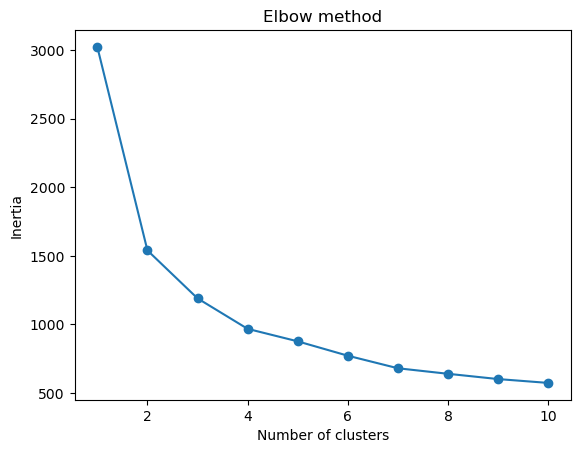

In [33]:
inertias = []						#prepare to store the inertia for each cluster count to inertias
for i in range(1,11):					#to create a for loop
    kmeans = KMeans(n_clusters=i)			#to use the k-means and set the number of clusters to be i
    kmeans.fit(clustering_dataset)				#to cluster the given dataset dfMPG
    inertias.append(kmeans.inertia_)

#inertia = kmeans.inertia_  #Inertia is a measure of how well a dataset is clustered using the K-means algorithm

plt.plot(range(1,11), inertias, marker='o')		#to plot a scree plot for you to determine the number of clusters
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Q8: Provide the cluster centres and interpret them. <font face="Calibri" size=3.0 color='#3543cd'> (Hint: You can initialise your kmeans by setting `kmeans = KMeans(n_clusters=3, init='random', max_iter=300, random_state=42)
`, where `n_clusters=3` means 3-means, `init='random'` means the initial cluster centres are randomly set, `max_iter=300` means the maximum number of the iteration steps is 300, `random_state=42` means the seed of the random number is 42.<font>

In [38]:
kmeans = KMeans(n_clusters=3, init='random', max_iter=300, random_state=42) 
kmeans.fit(clustering_dataset)

labels = kmeans.labels_
centers = kmeans.cluster_centers_   #luster centres
print("the cluster centres are:",centers)

centers_data = pd.DataFrame()

centers_data["feature"]  = clustering_dataset.columns
centers_data["Centre_1"] = centers[0]
centers_data["Centre_2"] = centers[1]
centers_data["Centre_3"] = centers[2]

print(centers_data)


the cluster centres are: [[-1.17544857  1.56698964  1.54465313  1.56257293  1.45975901 -1.00725638
  -0.55994293 -0.7321241 ]
 [-0.27521109 -0.12075653 -0.04634777 -0.17709364  0.02142104  0.31427436
  -0.10126106 -0.49943667]
 [ 0.95080388 -0.79305519 -0.85247359 -0.73567424 -0.86908043  0.27951716
   0.42389652  0.91136185]]
            feature  Centre_1  Centre_2  Centre_3
0  Miles_Per_Gallon -1.175449 -0.275211  0.950804
1         Cylinders  1.566990 -0.120757 -0.793055
2      Displacement  1.544653 -0.046348 -0.852474
3        Horsepower  1.562573 -0.177094 -0.735674
4            Weight  1.459759  0.021421 -0.869080
5      Acceleration -1.007256  0.314274  0.279517
6        Model_Year -0.559943 -0.101261  0.423897
7            Origin -0.732124 -0.499437  0.911362


# Part B: Case study

This case study aims to forecast employment with the dataset *heart_failure_clinical_records_dataset.csv*, downloaded from https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records.
Based on this dataset, answer the eight questions in Part A.


## Summary
- Understand the hierarchical cluster analysis, and the $k$-means cluster analysis;
- Understand the use of cluster analysis.

## Suggested reading for the Next Lecture
- To review the following sections/chapter in the book **Raschka, S., & Mirjalili, V. (2019). Python machine learning: Machine learning and deep learning with Python, scikit-learn, and TensorFlow 2. Packt publishing ltd**:
   1. Chapter 12;
   1. Chapter 13; and
   1. Chapter 16.
- Alternatively, you can review the following sections/chapter in the book **An Introduction to Statistical Learning: with Applications in Python (Springer Texts in Statistics)**
   1. Sections 10.1, 10.2, and 10.5
- Lyu, Q., & Wu, S. (2025). Explainable artificial intelligence for business and economics: methods, applications and challenges. Expert Systems, 42(4), e70017. https://onlinelibrary.wiley.com/doi/full/10.1111/exsy.70017